# <p style="font-family:newtimeroman;font-size:250%;text-align:center;color:skyblue;">Iris Flower Classification </p>

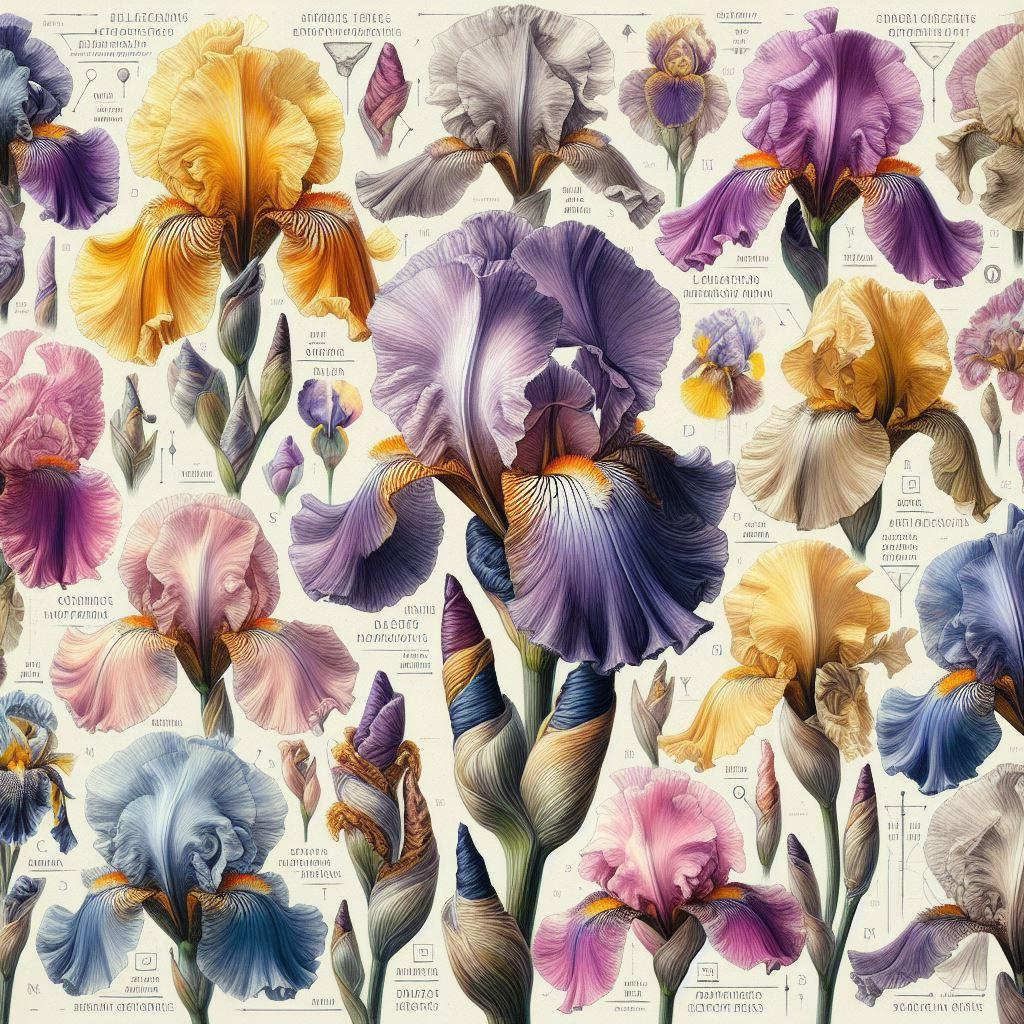


# <p style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;">About Data Iris Flower</p>

***The Iris dataset was used in R.A. Fisher's classic 1936 paper, The Use of Multiple Measurements in Taxonomic Problems, and can also be found on the UCI Machine Learning Repository.***

***[DataSet Link](https://www.kaggle.com/datasets/uciml/iris)***

***It includes three iris species with 50 samples each as well as some properties about each flower. One flower species is linearly separable from the other two, but the other two are not linearly separable from each other.***

***The columns in this dataset are***:

***`Id`***

***`SepalLengthCm`***

***`SepalWidthCm`***

***`PetalLengthCm`***

***`PetalWidthCm`***

***`Species`***



# <p style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;">Aims and Objective</p>

#### ***This notebook aims to conduct Exploratory Data Analysis (EDA) and implement Machine Learning (ML) techniques on the renowned Iris Flower dataset. The objectives are as follows:***

***This notebook is designed with beginners in mind, aiming to provide a practical learning experience by exploring the usage of various machine learning models and evaluating their performance. By employing three different models, we aim to showcase the versatility of machine learning in solving diverse problems.*** 

***At the outset, it's important to understand the significance of these models. Machine learning models serve as powerful tools for data analysis and decision-making in various domains. They enable us to extract valuable insights from data, make predictions, and automate tasks, thus enhancing efficiency and accuracy.***

***Throughout this notebook, we will delve into the workings of each model, highlighting their strengths and limitations. By evaluating their performance on real-world datasets, we can gain a deeper understanding of how these models operate in practice. This hands-on approach will empower beginners to grasp fundamental concepts and develop practical skills in machine learning.***

***1. **Data Exploration:***** ***Perform comprehensive EDA to gain insights into the dataset's structure, features, and distributions. Explore statistical summaries, visualizations, and correlations among variables.***

**2. **Model Development:**** ***Implement various ML algorithms such as Decision Trees, Random Forest, Support Vector Machines (SVM), and k-Nearest Neighbors (k-NN) for classification tasks. Evaluate each model's performance using appropriate metrics like accuracy, precision, recall, and F1-score.***


# <p style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;">Importing Libraries </p>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
import scipy.stats as stats
#Preprocessing
from sklearn.preprocessing import LabelEncoder , MinMaxScaler , QuantileTransformer , PowerTransformer
#Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
#Evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score , confusion_matrix
#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# <p style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;">Exploring Data</p>

###### **<h1 align="center"><span style="color:skyblue;">Load Data</span>**

In [ ]:
#Data 
df = pd.read_csv('/kaggle/input/iris/Iris.csv')

In [ ]:
# Drooping Id 
df.drop(columns=['Id'],inplace=True)

###### **<h1 align="center"><span style="color:skyblue;">Head of Data</span>**

In [ ]:
#Head Of Data
df.head()

###### **<h1 align="center"><span style="color:skyblue;">Shape of  Data</span>**

In [ ]:
# Checking the number of rows and columns
#Data
num_train_rows, num_train_columns = df.shape
#Printing the number of rows and columns.
print("Iris Flower Data:")
print(f"Number of Rows: {num_train_rows}")
print(f"Number of Columns: {num_train_columns}\n")


###### **<h1 align="center"><span style="color:skyblue;">Null Values of  Data</span>**

In [ ]:
# Null Values in Train 
df_null = df.isnull().sum().sum()

print(f'Null Count in Data: {df_null}')

###### **<h1 align="center"><span style="color:skyblue;">Duplicates Values of  Data</span>**

In [ ]:
# Count duplicate rows in train_data
data_duplicates = df.duplicated().sum()

# Print the results
print(f"Number of duplicate rows in Data: {data_duplicates}")

###### **<h1 align="center"><span style="color:skyblue;">Info of  Data</span>**

In [ ]:
#info 
df.info()

**Observations :**

***1. Our Data Contains Total `150Rows` and `6 Columns`.Data is Free From Null Values and Duplicates Values.***

***2. One Categorical Feature and 5 Numeric Features is in Data.***

###### **<h1 align="center"><span style="color:skyblue;">Descriptive Statistic Of Numerical Featres</span>**

In [ ]:
#Descriptive statistics
df.describe()

**Observations:**

- ***The Sepal Length ranges from [4.3] to [7.9] with a mean of [5.8433] cm.***
- ***The Sepal Width ranges from [2.0] to [4.4] with a mean of [3.0540] cm.***
- ***The Petal Length ranges from [1.0] to [6.9] with a mean of [3.758] cm.***
- ***The Petal Width ranges from [0.100000] to [2.500000] with a mean of [1.198667] cm.***

###### **<h1 align="center"><span style="color:skyblue;">Categorical Columns Of Data</span>**

In [ ]:
# Printing Columns That Have Dtype is Object or categorical.
object_columns = df.select_dtypes(include=['object']).columns
print(f'The Following Columns Have Dtype as Object \n: {object_columns}')
print(f'The Value Count of Categorical Columns is : {object_columns.value_counts().sum()}')

###### **<h1 align="center"><span style="color:skyblue;">Numerical Columns Of Data</span>**

In [ ]:
# Printing Columns That Have Dtype is FLoat or int
float_columns = df.select_dtypes(include=['float','int']).columns
print(f'The Following Columns Have Dtype as Float and int :\n{float_columns}')
print(f'The Value Count of Float Columns is : {float_columns.value_counts().sum()}')

# <p style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;">Eda (Exploraitary Data Analysis)</p>

***Exploratory Data Analysis (EDA) is a crucial initial step in data analysis, aimed at understanding the data's characteristics and uncovering insights. It involves techniques like summary statistics, data visualization, and data cleaning to gain familiarity with the dataset. EDA helps identify patterns, trends, and outliers, guiding further analysis and hypothesis formulation. It assists in determining the suitability of data for specific analyses, detecting errors, and selecting appropriate models. EDA is iterative and interactive, involving constant refinement as insights are uncovered. It aids in making informed decisions, generating hypotheses, and preparing data for modeling, enhancing the overall understanding of the dataset.***

# <p style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;">Uni-Variate Analysis</p>

***Univariate analysis is a statistical method used to analyze a single variable at a time. It focuses on understanding the characteristics and distribution of a single variable, such as its central tendency, dispersion, and shape of the distribution. Common techniques in univariate analysis include measures of central tendency (e.g., mean, median, mode), measures of dispersion (e.g., variance, standard deviation), and graphical representations (e.g., histograms, box plots). By examining a single variable in isolation, univariate analysis provides insights into its behavior and variability, serving as a foundational step in statistical analysis to understand the individual characteristics of variables before exploring their relationships with other variables.***

In [ ]:
def print_feature_stats(df):
    numeric_features = df.select_dtypes(include=['float64', 'int64']).columns
    for feature in numeric_features:
        feature_data = df[feature]
        feature_mean = feature_data.mean()
        feature_median = feature_data.median()
        feature_std = feature_data.std()
        feature_count = feature_data.count()
        
        print(f"Feature: {feature}")
        print(f"Mean: {feature_mean:.2f}")
        print(f"Median: {feature_median:.2f}")
        print(f"Standard Deviation: {feature_std:.2f}")
        print(f"Count: {feature_count}")
        print()
print_feature_stats(df)

#### <h1 style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;">Numerical Features</h1>

In [ ]:
numerical_features = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
# Calculate the number of rows and columns needed for subplots
num_cols = 2
num_rows = (len(numerical_features) + num_cols - 1) // num_cols  # Calculate number of rows based on columns

# Create subplots with the calculated number of rows and columns
fig = make_subplots(rows=num_rows, cols=num_cols)

# Loop through numerical columns and add boxplots with color
for i, col in enumerate(numerical_features, start=1):
    row_num = (i - 1) % num_rows + 1
    col_num = (i - 1) // num_rows + 1
    fig.add_trace(
        go.Box(
            x=df[col],
            name=col,
            marker_color='#1f77b4',  # Set box color
            line_color='#1f77b4'     # Set mean line color
        ),
        row=row_num,
        col=col_num
    )

# Update layout
fig.update_layout(title_text="Boxplots of Numerical Columns", showlegend=False,)

# Show the plot
fig.show()


**Observation :**

***From Above Visualization , we Can See that `SepalWidthCm` Contains Some Outliers , and Other all are Perfectly Fine***

#### <h1 style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;">Species Count</h1>

In [ ]:
# Define custom colors
# custom_colors = ['#1f77b4', 'skyblue', 'lightblue']
custom_colors = ['#1f77b4', 'skyblue', 'cornflowerblue']


# Create a pie chart with custom colors
fig_pie = px.pie(values=[50, 50, 50],
                 names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'],
                 title='Pie Chart of Species Counts',
                 color_discrete_sequence=custom_colors)

# Show the pie chart
fig_pie.show()


**Observation :**

***All The Species Have Same Values Count***

# <p style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;">Bi-Variate Analysis</p>

***Bivariate analysis is a statistical method used to explore the relationship between two variables simultaneously. It focuses on understanding how changes in one variable are associated with changes in another variable. By examining the correlation, association, or dependency between two variables, bivariate analysis helps uncover patterns, trends, and dependencies in the data. This analysis is crucial for identifying potential cause-and-effect relationships, determining the strength and direction of the association between variables, and gaining insights into their joint behavior. Bivariate analysis is widely used in various fields, including economics, social sciences, healthcare, and environmental studies, to inform decision-making and drive actionable insights from data.***

#### <h1 style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;"> SepalLengthCm vs Species</h1>

In [ ]:
# Create a box plot to show the relationship between a numerical variable and a categorical variable
fig_boxplot = px.box(df, x="Species", y="SepalLengthCm", title="Box Plot of SepalLengthCm by Species",
                     color='Species',  # Set box color based on Species
                     color_discrete_sequence=custom_colors  # Custom color sequence
                    )

# Update layout
fig_boxplot.update_layout(xaxis_title="Species", yaxis_title="SepalLengthCm",)

# Show the box plot
fig_boxplot.show()

**Observation:**

***From the above visualization, it is evident that the species *`Virginica`* exhibits a higher average value of Sepal Length (SepalLengthCm) compared to the other species. Conversely, the *`Setosa`* species demonstrates a lower average value of Sepal Length.***

***Maximum value of Sepal Length Of Setosa Species is `5.8cm` and Lower value of Setosa Species is `4.3cm`.***

***Maximum value of Sepal Lenght of Versicolor Species is `7cm` and lower values of `4.9`.***

***Max value of Sepal Length of Virginica Species is `7.9cm` and Lower value of `5.6`.***

#### <h1 style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;"> SepalWidthCm vs Species</h1>

In [ ]:
# Create a box plot to show the relationship between a numerical variable and a categorical variable
fig_boxplot = px.box(df, x="Species", y="SepalWidthCm", title="Box Plot of SepalWidthCm by Species",
                     color='Species',  # Set box color based on Species
                     color_discrete_sequence=custom_colors  # Custom color sequence
                    )

# Update layout
fig_boxplot.update_layout(xaxis_title="Species", yaxis_title="SepalWidthCm")

# Show the box plot
fig_boxplot.show()

**Observation:**

***From the above visualization, it is evident that the species *`Setosa`* exhibits a higher average value of Sepal Width (SepalWidthCm) compared to the other species. Conversely, the *`Versicolor`* species demonstrates a lower average value of Sepal Width.***

***Max Value Of Sepal Width Of Species Setosa is `4.4cm` and lower average value of Sepal Width is `2.3cm`.***

***Max Value Of Sepal Width Of Species Versicolor is `3.4cm` and lower values is `2cm`.***

***Max Value Of Sepal Width Of Species Virginica is `3.8cm` and Lower value is `2.2cm`.***

#### <h1 style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;"> PetalLengthCm vs Species</h1>

In [ ]:
# Create a box plot to show the relationship between a numerical variable and a categorical variable
fig_boxplot = px.box(df, x="Species", y="PetalLengthCm", title="Box Plot of PetalLengthCm by Species",
                     color='Species',  # Set box color based on Species
                     color_discrete_sequence=custom_colors  # Custom color sequence
                    )

# Update layout
fig_boxplot.update_layout(xaxis_title="Species", yaxis_title="PetalLengthCm",)

# Show the box plot
fig_boxplot.show()

**Observation:**

***From the above visualization, it is evident that the species *`Virginica`* exhibits a higher average value of Petal Length (PetalLengthCm) compared to the other species. Conversely, the *`Setosa`* species demonstrates a lower average value of Petal Length.***

***Max value of Petal Length of Setosa Species is `1.9cm` and lower average value of Setosa is `1`.***

***Max Value of Petal Length of Versicolor Species is `5.1` and lower average value of Versicolor is `3.3`.***

***Max Value Of Petal Lenght of Virginica Species is `6.9` and lower average values of Virginica is `4.5`.***

#### <h1 style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;"> PetalWidthCm vs Species</h1>

In [ ]:
# Create a box plot to show the relationship between a numerical variable and a categorical variable
fig_boxplot = px.box(df, x="Species", y="PetalWidthCm", title="Box Plot of PetalWidthCm by Species",
                     color='Species',  # Set box color based on Species
                     color_discrete_sequence=custom_colors  # Custom color sequence
                    )

# Update layout
fig_boxplot.update_layout(xaxis_title="Species", yaxis_title="PetalWidthCm",)

# Show the box plot
fig_boxplot.show()

**Observation:**

***From the above visualization, it is evident that the species *`Virginica`* exhibits a higher average value of Petal Width (PetalWidthCm) compared to the other species. Conversely, the *`Setosa`* species demonstrates a lower average value of Petal Width.***

***Max value of Petal Length of Setosa Species is `0.6cm` and lower average value of Setosa is `0.1`.***

***Max Value of Petal Length of Versicolor Species is `1.8cm` and lower average value of Versicolor is `1cm`.***

***Max Value Of Petal Lenght of Virginica Species is `2.5cm` and lower average values of Virginica is `1.4cm`.***

# <p style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;">Numerical Features Distribution</p>


In [ ]:
numeric_features = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]

# Calculate the number of rows and columns for subplots
num_features = len(numeric_features)
num_rows = math.ceil(num_features / 4)  # Adjust the number 4 based on how many plots you want per row
num_cols = min(num_features, 4)

# Set up the figure and axes for subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(5*num_cols, 5*num_rows))

# Flatten the axes for easier iteration
axes = axes.flatten()

sns.set_theme(style="darkgrid")

# Loop through each numerical feature and create a distribution plot with custom bar color
for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_facecolor('skyblue')  # Set background color to skyblue
# Remove any unused subplots
for i in range(num_features, num_rows*num_cols):
    fig.delaxes(axes[i])

# Adjust layout
plt.tight_layout()
plt.show()

**Observations:**

***Upon reviewing the plots above, it's evident that the distribution of Numerical Features does not follow a Gaussian distribution. Therefore, our next step is to transform the distribution of Numerical Features to adhere to a Gaussian distribution.***

# <p style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;">Normalization Numerical Features</p>


#### <h1 style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;"> Quantile Transformer</h1>

***Quantile Transformer is a data transformation technique used in statistics and machine learning to normalize numerical features. It works by transforming the probability distribution of the data to approximately follow a uniform or normal distribution. This transformation helps in reducing skewness and making the data more suitable for certain statistical analyses or machine learning algorithms that assume normality or require standardized features.***

1. **Standardizing Distributions:** ***It transforms the original data distribution to closely resemble a uniform or normal distribution, which is often preferred for various statistical analyses and modeling tasks.***

2. **Skewness Reduction:** ***By redistributing the data values to follow a more symmetrical distribution, Quantile Transformer effectively reduces skewness, making the data more balanced and easier to analyze.***

3. **Outlier Handling:** ***The transformation can mitigate the impact of outliers by spreading the data across different quantiles, potentially making the dataset more robust to extreme values.***

4. **Enhancing Model Performance:** ***Normalizing numerical features using Quantile Transformer can improve the performance of machine learning models, especially those sensitive to the scale and distribution of input features, such as linear regression and neural networks.***

***Overall, Quantile Transformer plays a crucial role in preprocessing numerical data, facilitating better data normalization and improving the quality of subsequent analyses or model predictions.***

In [ ]:
def quantile_transform(data,cols):
    # Transformer 
    qt = QuantileTransformer(output_distribution='normal')
    #Use a Loop to Transformer
    for col in cols:
        data[col] = qt.fit_transform(data[[col]])
    return data
#Transform Data
df = quantile_transform(df,numeric_features) 

In [ ]:
# Function to create QQ plots
def plot_qq(df_qt, feature, ax):
    stats.probplot(df_qt[feature], dist="norm", plot=ax)
    ax.get_lines()[1].set_linestyle('--')
    ax.set_title(f"QQ Plot for {feature}")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Ordered Values")

# Calculate the number of rows and columns for subplots
num_features = len(numeric_features)
num_cols = 3  # Number of plots per row
num_rows = math.ceil(num_features / num_cols)

# Set up the figure and axes for subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(5*num_cols, 5*num_rows))

# Flatten the axes for easier iteration
axes = axes.flatten()

# Loop through each numerical feature and create a QQ plot
for i, col in enumerate(numeric_features):
    plot_qq(df, col, axes[i])
    axes[i].set_facecolor('skyblue') 

# Remove any unused subplots
for i in range(num_features, num_rows*num_cols):
    fig.delaxes(axes[i])

# Adjust layout
plt.tight_layout()
plt.show()

**MileStone:**

***Now our data exhibits a distribution closely resembling a Gaussian distribution. The Quantile Transformer has proven to be a valuable tool in achieving this transformation.***

# <p style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;">Model Building</p>


***Model building is the process of creating and refining mathematical representations, typically using algorithms or statistical techniques, to make predictions, classifications, or gain insights from data. It involves selecting appropriate features, choosing a suitable algorithm, training the model on labeled data, and evaluating its performance using metrics like accuracy or mean squared error. Model building requires iterative experimentation, parameter tuning, and validation to ensure the resulting model generalizes well to unseen data. It is a fundamental step in machine learning and data analysis, enabling informed decision-making, pattern recognition, and predictive analytics across various domains and industries.***

In [ ]:
def evaluate_results(y_test, y_pred):
    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Print evaluation metrics
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    return accuracy, precision, recall, f1

#### <h1 style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;"> SVM (Support Vector Machine)</h1>

#### **Support Vector Machine (SVM):** 

***Support Vector Machine (SVM) is a powerful supervised learning algorithm used for classification and regression tasks. It is particularly effective in high-dimensional spaces and is widely used in fields such as image recognition, text classification, and bioinformatics.*** 

#### **Importance of SVM:**

***SVM is highly effective in dealing with complex datasets where there is a clear margin of separation between classes. It works well even in cases where the number of dimensions exceeds the number of samples. SVMs can handle both linear and non-linear data through the use of different kernel functions, making them versatile in various scenarios.*** 
***Additionally, SVMs offer robustness against overfitting, as they aim to maximize the margin between classes, thereby promoting generalization to unseen data. Moreover, SVMs are computationally efficient due to the use of a subset of training points called support vectors, which significantly reduces memory usage and speeds up training.***


In [ ]:
# Splitting the data into Features & Targets
X = df.drop(columns='Species', axis=1)
y = df['Species']

# Splitting the data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the SVM model
svm_classifier = SVC(kernel='linear', C=1.0, decision_function_shape='ovr')
svm_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_classifier.predict(X_test)

# Evaluate the model
accuracy_svm = evaluate_results(y_test,y_pred_svm)

#### <h1 style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;"> K-Nearest Neighbors (KNN)</h1>

#### **Importance of K-Nearest Neighbors (KNN):**

***K-Nearest Neighbors (KNN) is a simple yet powerful algorithm used in both classification and regression tasks. Its simplicity lies in its intuitive approach: it classifies data points based on the majority class of their nearest neighbors. KNN's flexibility makes it suitable for various applications, particularly in situations where the data distribution is not well-defined or linearly separable. Additionally, KNN does not require training data for model building, making it computationally efficient for small to medium-sized datasets.***

***One of the key advantages of KNN is its non-parametric nature, meaning it does not make any assumptions about the underlying data distribution. This makes KNN robust to outliers and noise in the data. Moreover, KNN's performance tends to improve as the size of the training dataset grows, as it relies on local information rather than global patterns. Despite its simplicity, KNN can often perform competitively with more complex algorithms, especially in scenarios where the decision boundary is highly irregular or nonlinear.***


In [ ]:
# Split the data into features (X) and target (y)
X = df.drop(columns='Species')
y = df['Species']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred_knn = knn_classifier.predict(X_test)

#Evaluate 
accuracy_knn = evaluate_results(y_test, y_pred_knn)

#### <h1 style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;">Decision Tree Classifier </h1>

***Decision Trees are powerful machine learning models used for both classification and regression tasks. They work by recursively partitioning the input space into regions, with each split being chosen to minimize impurity or maximize information gain. One of the main advantages of Decision Trees is their interpretability, as they can be easily visualized and understood by humans. They are also robust to outliers and can handle both numerical and categorical data without requiring preprocessing. Moreover, Decision Trees implicitly perform feature selection by selecting the most informative features at each split. However, they are prone to overfitting, especially with deep trees, and can be sensitive to small variations in the training data. Despite these limitations, Decision Trees are widely used in practice due to their simplicity, interpretability, and ability to handle complex datasets.***

In [ ]:
# Split the data into features (X) and target (y)
X = df.drop(columns='Species')
y = df['Species']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier()

# Train the model
dt_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_classifier.predict(X_test)

# Evaluate the model
accuracy_dt = evaluate_results(y_test, y_pred_dt)

# <p style="font-family:newtimeroman;font-size:200%;text-align:center;color:skyblue;">Conclusion !!!</p>


In [ ]:
print('1. We have trained three models to evaluate their performance:')
print(f'- The SVM model achieved an accuracy of {accuracy_svm[0]:.2f}.')
print(f'- The KNN model achieved an accuracy of {accuracy_knn[0]:.2f}.')
print(f'- The Decision Tree model achieved an accuracy of {accuracy_dt[0]:.2f}.')
print(f'As we Know All The Models are Performing Well and giving Accuracy of 100%')

In [ ]:

# Define model names and accuracies
model_names = ['SVM', 'KNN', 'Decision Tree']
accuracies = [accuracy_svm[0], accuracy_knn[0], accuracy_dt[0]]

# Create a bar plot
fig = go.Figure(data=[go.Bar(x=model_names, y=accuracies, marker_color='skyblue')])
fig.update_layout(
                  title='Model Accuracies',
                  xaxis_title='Model',
                  yaxis_title='Accuracy',
                  yaxis=dict(tickformat=".2%"))
fig.show()
